In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
def load_img():
    blank_img =np.zeros((600,600))
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img,text='NANDU',org=(50,300), fontFace=font,fontScale= 5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
    return blank_img

In [15]:
def display_img(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')
    plt.show()

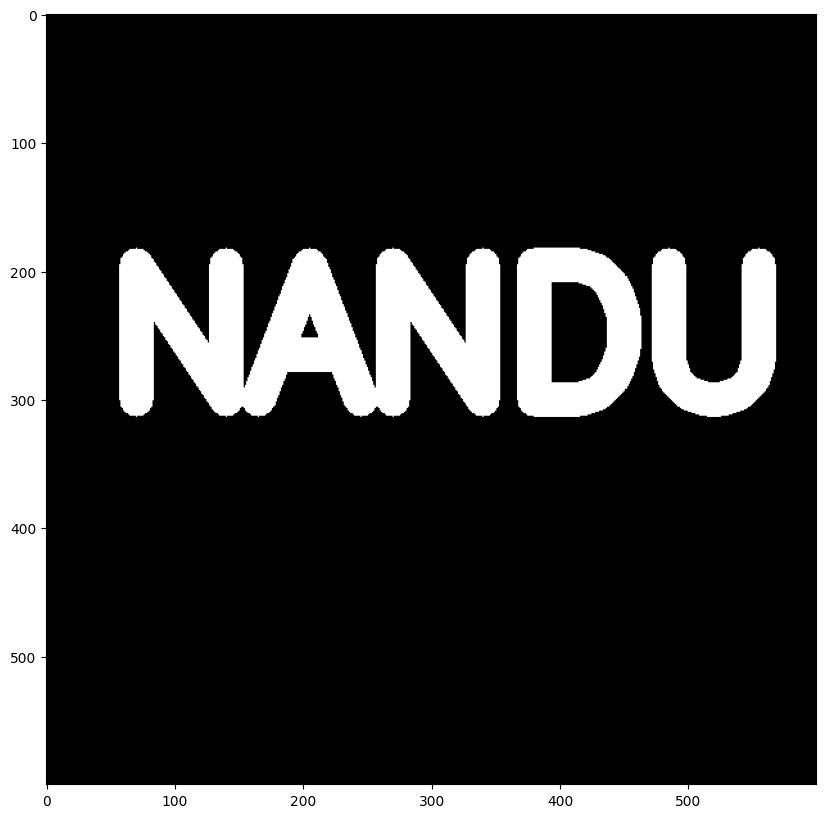

In [16]:
img = load_img()
display_img(img)

EROSION

In [17]:
kernel = np.ones((5,5),dtype='uint8')

In [18]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [19]:
erosion1 = cv2.erode(img, kernel, iterations=1)

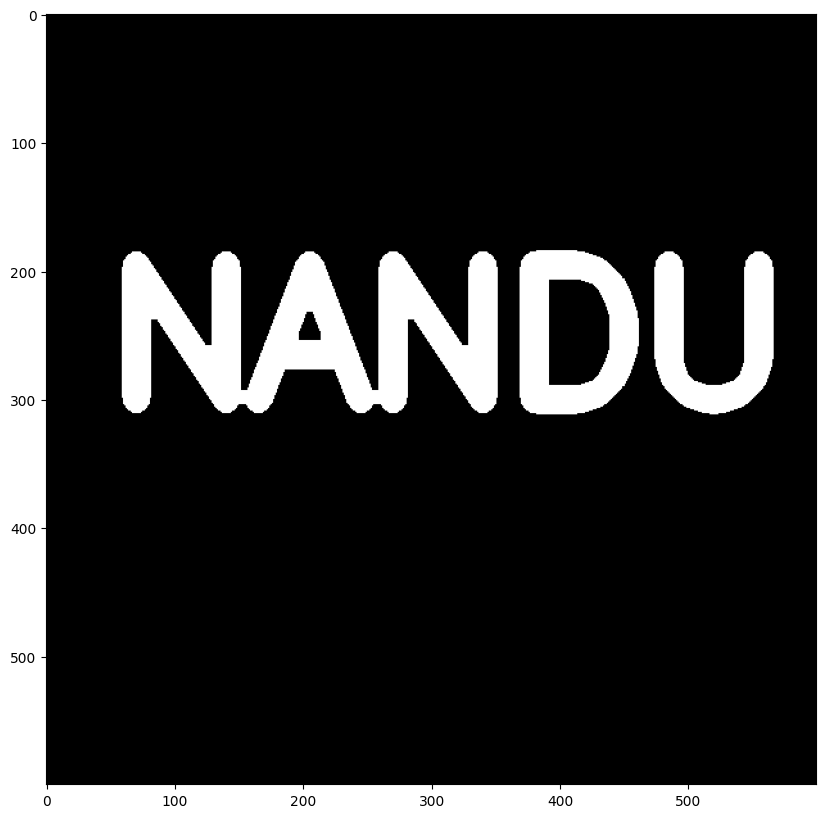

In [20]:
display_img(erosion1)

OPENING

In [21]:
img = load_img()

In [23]:
white_noise = np.random.randint(low=0,high=3,size=(600,600))

In [24]:
white_noise

array([[0, 1, 0, ..., 2, 1, 2],
       [0, 0, 2, ..., 0, 0, 2],
       [0, 2, 0, ..., 0, 0, 0],
       ...,
       [1, 2, 0, ..., 1, 1, 2],
       [2, 0, 2, ..., 2, 2, 2],
       [2, 0, 1, ..., 1, 2, 1]], shape=(600, 600), dtype=int32)

In [25]:
img.max()

np.float64(255.0)

In [27]:
white_noise.max()

np.int32(2)

In [29]:
white_noise = white_noise*255

In [30]:
white_noise

array([[  0, 255,   0, ..., 510, 255, 510],
       [  0,   0, 510, ...,   0,   0, 510],
       [  0, 510,   0, ...,   0,   0,   0],
       ...,
       [255, 510,   0, ..., 255, 255, 510],
       [510,   0, 510, ..., 510, 510, 510],
       [510,   0, 255, ..., 255, 510, 255]], shape=(600, 600), dtype=int32)

In [31]:
noise_img = white_noise+img

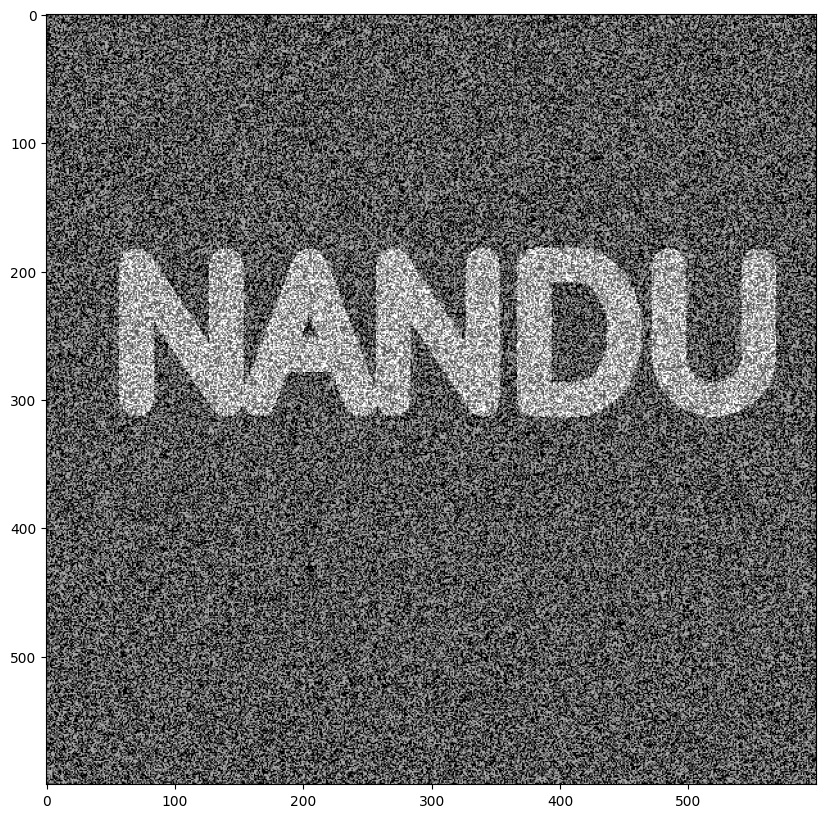

In [32]:
display_img(noise_img)   

In [33]:
opening = cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)

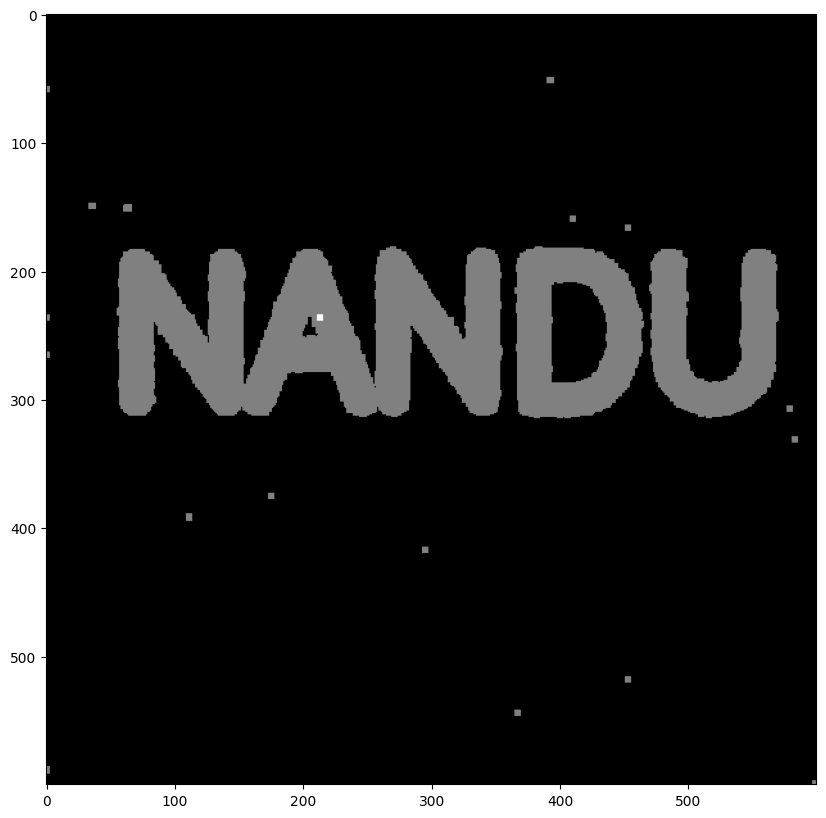

In [34]:
display_img(opening)

CLOSING

In [35]:
img = load_img()

In [36]:
black_noise = np.random.randint(low=0,high=2,size=(600,600))

In [37]:
black_noise

array([[0, 1, 1, ..., 1, 0, 1],
       [1, 0, 0, ..., 0, 1, 0],
       [1, 0, 1, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 1],
       [0, 1, 0, ..., 0, 1, 1],
       [1, 1, 1, ..., 0, 0, 0]], shape=(600, 600), dtype=int32)

In [38]:
black_noise= black_noise * -255

In [39]:
black_noise_img = img + black_noise

In [40]:
black_noise_img

array([[   0., -255., -255., ..., -255.,    0., -255.],
       [-255.,    0.,    0., ...,    0., -255.,    0.],
       [-255.,    0., -255., ..., -255.,    0.,    0.],
       ...,
       [   0.,    0., -255., ...,    0.,    0., -255.],
       [   0., -255.,    0., ...,    0., -255., -255.],
       [-255., -255., -255., ...,    0.,    0.,    0.]], shape=(600, 600))

In [41]:
black_noise_img[black_noise_img==-255] = 0

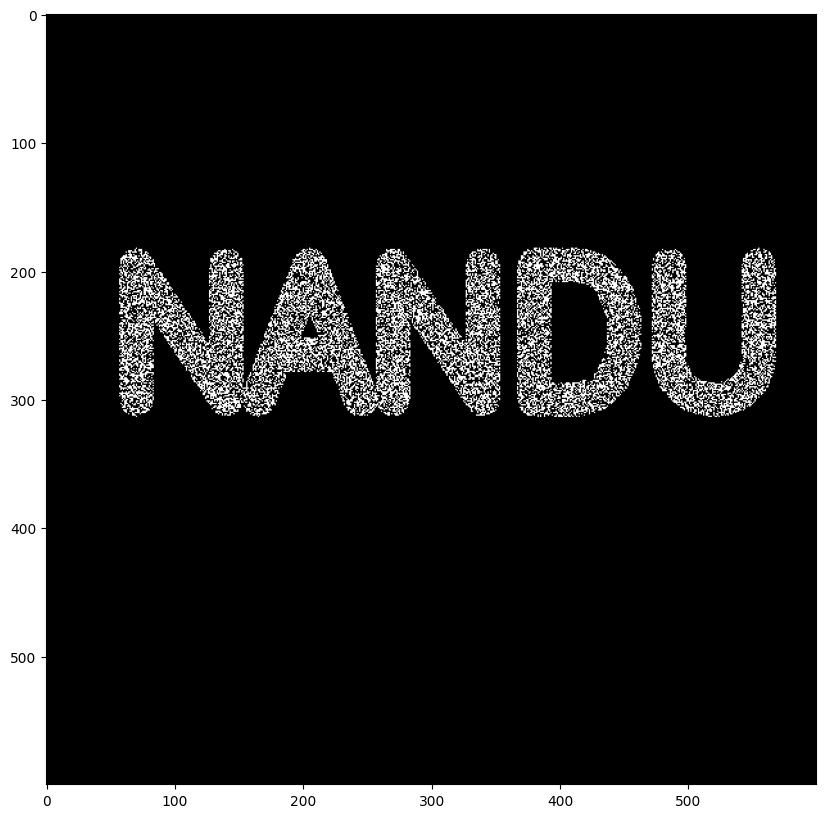

In [42]:
display_img(black_noise_img)

In [43]:
closing = cv2.morphologyEx(black_noise_img, cv2.MORPH_CLOSE, kernel)

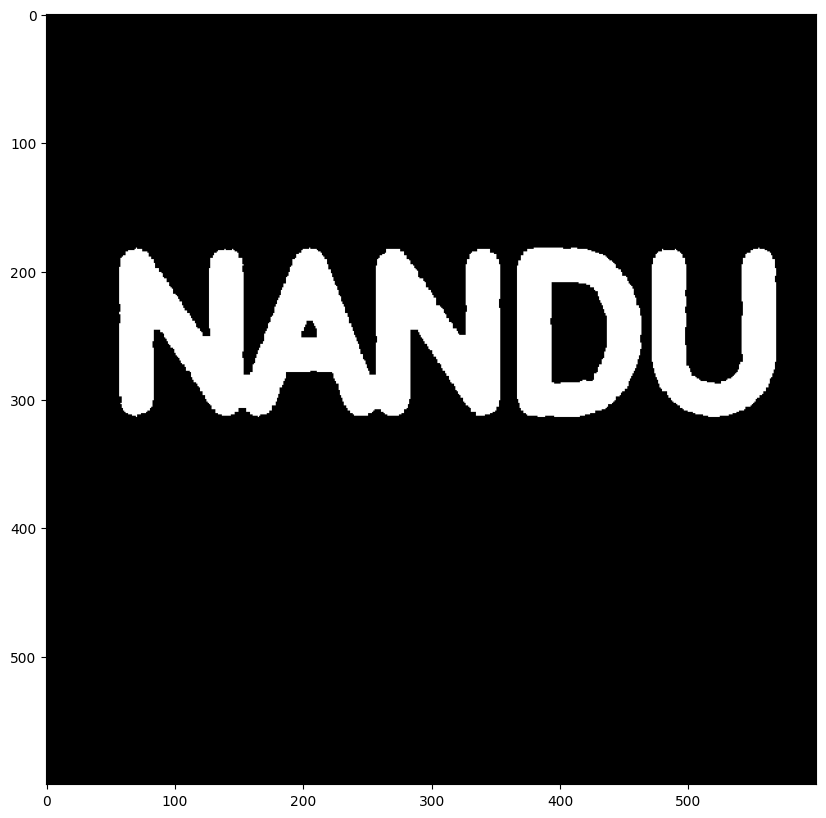

In [44]:
display_img(closing)

Morphological Gradient

In [45]:
img = load_img()

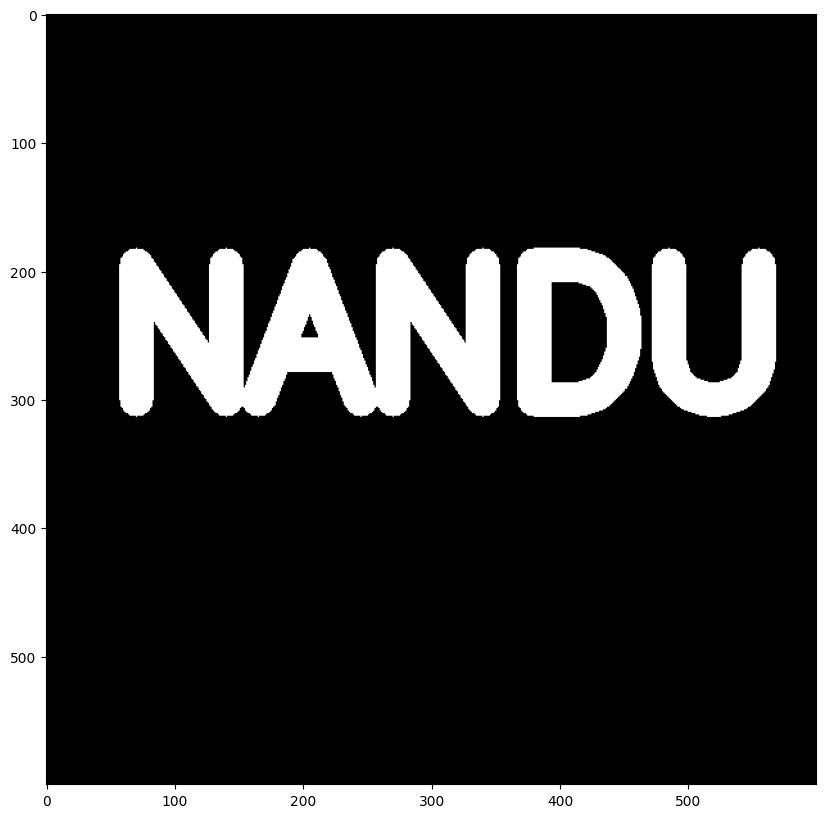

In [46]:
display_img(img)

In [47]:
gradient = cv2.morphologyEx(img,cv2.MORPH_GRADIENT,kernel)

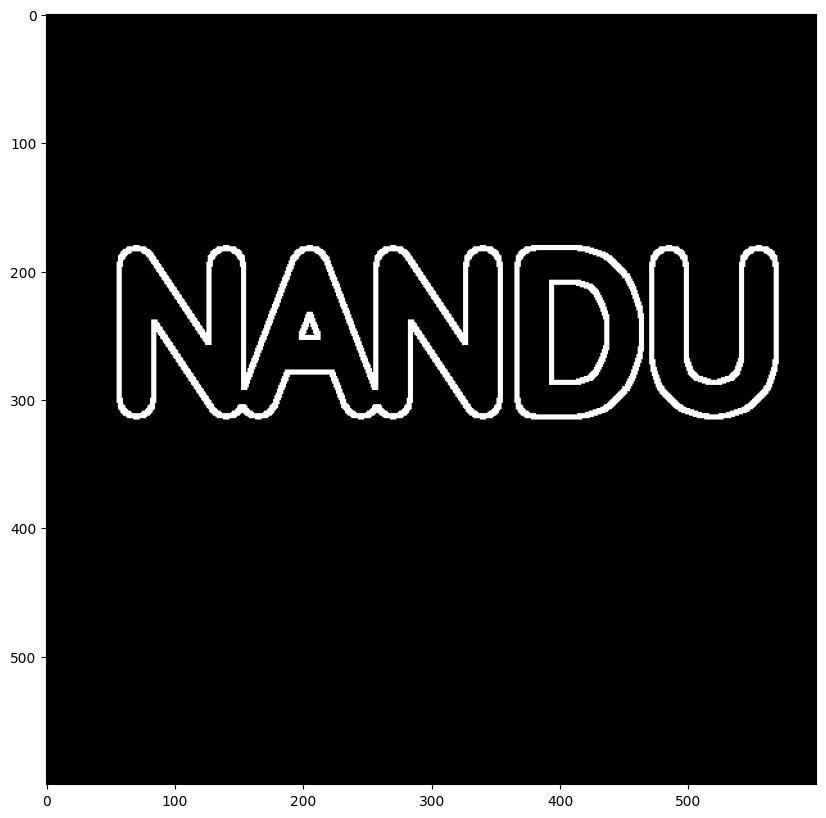

In [48]:
display_img(gradient)